### hnadwritten text (number identification) using the neural network 
    - let's say we have 0-9 numbers : 10 class for identification.
    - use softmax activation function.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras import Sequential
from tensorflow.keras.activations import linear, relu, sigmoid

In [ ]:
# UNQ_C1
# GRADED CELL: my_softmax
def my_softmax(z):  
    """ Softmax converts a vector of values to a probability distribution.
    Args:
      z (ndarray (N,))  : input data, N features
    Returns:
      a (ndarray (N,))  : softmax of z
    """    
    
    ### START CODE HERE ### 
    N = np.shape(z)
    print(f"N: {N}: so N is the numbers which we need to classify: actual N val :{np.shape(z)[0]}")
    a = np.zeros(np.shape(z)[0])
    
    for i in range(np.shape(z)[0]):
        a[i] = np.exp(z[i])/ np.sum(np.exp(z)) 
    
    
    ### END CODE HERE ### 
    return a

In [ ]:
z = np.array([1., 2., 3., 4.])
a = my_softmax(z)
atf = tf.nn.softmax(z)
print(f"my_softmax(z):         {a}")
print(f"tensorflow softmax(z): {atf}")

# BEGIN UNIT TEST  
# test_my_softmax(my_softmax)
# END UNIT TEST  

In [ ]:
from deep_learning_package.utils import *

# # --- THE FIX IS HERE ---
# # Pass the FUNCTION ITSELF (my_softmax), not a pre-calculated array (a)
interactive_softmax_plot(z_init=z, softmax_func=my_softmax)

<a name="4"></a>
## 4 - Neural Networks

In last weeks assignment, you implemented a neural network to do binary classification. This week you will extend that to multiclass classification. This will utilize the softmax activation.


<a name="4.1"></a>
### 4.1 Problem Statement

In this exercise, you will use a neural network to recognize ten handwritten digits, 0-9. This is a multiclass classification task where one of n choices is selected. Automated handwritten digit recognition is widely used today - from recognizing zip codes (postal codes) on mail envelopes to recognizing amounts written on bank checks. 


<a name="4.2"></a>
### 4.2 Dataset

You will start by loading the dataset for this task. 
- The `load_data()` function shown below loads the data into variables `X` and `y`


- The data set contains 5000 training examples of handwritten digits $^1$.  

    - Each training example is a 20-pixel x 20-pixel grayscale image of the digit. 
        - Each pixel is represented by a floating-point number indicating the grayscale intensity at that location. 
        - The 20 by 20 grid of pixels is “unrolled” into a 400-dimensional vector. 
        - Each training examples becomes a single row in our data matrix `X`. 
        - This gives us a 5000 x 400 matrix `X` where every row is a training example of a handwritten digit image.

$$X = 
\left(\begin{array}{cc} 
--- (x^{(1)}) --- \\
--- (x^{(2)}) --- \\
\vdots \\ 
--- (x^{(m)}) --- 
\end{array}\right)$$ 

- The second part of the training set is a 5000 x 1 dimensional vector `y` that contains labels for the training set
    - `y = 0` if the image is of the digit `0`, `y = 4` if the image is of the digit `4` and so on.

$^1$<sub> This is a subset of the MNIST handwritten digit dataset (http://yann.lecun.com/exdb/mnist/)</sub>

In [ ]:
import os
from pathlib import Path 
root_dir = Path.cwd().parent
print(f"root_dir: {root_dir}")
datapath = "data/mnist_image_data"
full_datapath = os.path.join(root_dir, datapath)
print(f"full_datapath: {full_datapath}")
files= os.listdir(full_datapath)
# print(f"files: {files}")    
Xdata = np.load(os.path.join(full_datapath, "X.npy"))
ydata = np.load(os.path.join(full_datapath, "y.npy"))
print(f"Xdata shape: {Xdata.shape}")
print(f"ydata shape: {ydata.shape}")

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(Xdata,ydata,test_size=0.2,random_state=42)
print(f"shape of xtrain:{X_train.shape}")
print(f"shape of ytrain:{y_train.shape}")
print(f"shape of xtrain:{y_test.shape} and  \n xtest:{X_test.shape}")

### here we can see the numerical image number recognition data matrix pixels from rows and column to the a row matrix: (1,400)
- we can see some image lets' say in 10x10 image grid.
- image.reshape(20,20) 
- 

image_sel shape: (40, 400)
label_sel shape: (40, 1)


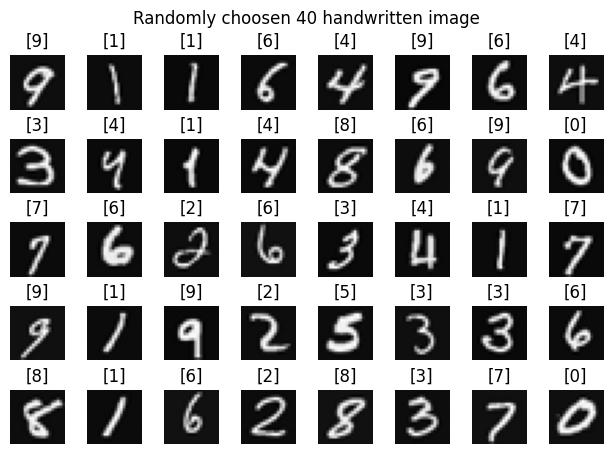

In [ ]:
import random
num_image_disp = 40
rnd_num_selection = np.random.permutation(X_train.shape[0])[:num_image_disp]
# print(f"rnd_num_selection: {rnd_num_selection}")
image_sel = X_train[rnd_num_selection]
label_sel = y_train[rnd_num_selection]
# print(label_sel)
print(f"image_sel shape: {image_sel.shape}")
print(f"label_sel shape: {label_sel.shape}")
plt.figure(figsize=(6.5,4.5))
plt.suptitle(f"Randomly choosen {num_image_disp} handwritten image")
for i in range(num_image_disp):
    plt.subplot(5,8,i+1)
    plt.imshow(image_sel[i].reshape(20,20).T, cmap="gray")
    plt.axis("off")
    plt.title(label_sel[i])
    plt.tight_layout(pad=0.5)
plt.show()

In [ ]:
model = Sequential(
    [
    # Add the Input layer as the very first item
    tf.keras.Input(shape=(400,)), # # Replace 400 with your actual number of input features!
    Dense(units=30,activation='relu'),
    Dense(units=15,activation='relu'),
    Dense(units=10,activation='linear')
    ],name='my_model'           
)

In [ ]:
model.compile(loss=tf.keras.Optimizer(adam,true_logits), )